# Lab 4: Improving and Comparing Machine Learning Models

**Name:** Muhammad Anees  
**Student ID:** 023-24-0251  
**Section:** **[H]**  
**GitHub Profile:** https://github.com/Anees-Memon-Hub/ML-Practice

**Kaggle Profile:** https://www.kaggle.com/aneesmemon  
**Dataset:** Telco Customer Churn (`clean_churn.csv`)




In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


sns.set_theme(style="whitegrid")


DATA_FILE = "clean_churn.csv"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print("clean_churn.csv was not found.")
        print("Please select your clean_churn.csv file in the upload dialog.")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(
            "clean_churn.csv was not found. Place it in the notebook folder before running."
        )

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        "clean_churn.csv is still missing. Please upload the file and run this cell again."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())


Dataset loaded successfully.
Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,Yes,43,Yes,Yes,Fiber Optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,Male,0,Yes,Yes,67,Yes,Yes,Fiber Optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,Female,1,No,No,1,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,Female,1,Yes,No,72,Yes,Yes,Dsl,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,Female,0,No,No,69,Yes,No,Dsl,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


---
# 1. Decision Tree Baseline

### Tasks 1–2
Reload the cleaned Lab 2 dataset, recreate `X` and `y`, use the same train/test split as Lab 3, and retrain the chosen Decision Tree.


In [ ]:
# Create X and y 
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

# One-hot encode categorical features.
# drop_first=True avoids redundant dummy variables.
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn rate:", round(y.mean(), 4))
print("Missing values in X:", int(X.isna().sum().sum()))


X shape: (7043, 30)
y shape: (7043,)
Churn rate: 0.2654
Missing values in X: 0


C:\Users\memon\AppData\Local\Temp\ipykernel_18048\3999127483.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [4]:
# Same train/test split 
# Keep these settings identical to the Lab 3 split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows    :", len(X_test))


Training rows: 5634
Test rows    : 1409


In [ ]:
#  Decision Tree baseline
best_depth = 4

dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

print("Decision Tree Baseline (max_depth=4)")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-score :", round(dt_f1, 4))


Decision Tree Baseline (max_depth=4)
Accuracy : 0.7835
Precision: 0.5856
Recall   : 0.631
F1-score : 0.6075


**Interpretation:** The Decision Tree at depth four is the standard for the rest of the lab. All accuracy measures—accuracy, precision, recall, and F1-score—are included to ensure that the model is not judged solely on accuracy.

---
# 2. Random Forest

### Tasks 3–4
Train a Random Forest using the same training data and explain why an ensemble can generalize better than a single unrestricted tree.


In [6]:
#Default Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")
print("Number of trees:", rf_model.n_estimators)


Random Forest trained successfully.
Number of trees: 200


**Task 4 — Explanation:** It is possible that Random Forest may be more likely to generalize as compared to an unconstrained Decision Tree since the latter is composed of many decision trees, which have been trained on various samples and subsets of features.

---
# 3. Model Evaluation

### Task 5
Evaluate the Random Forest using accuracy, precision, recall, F1-score, and a confusion matrix.


In [7]:
#Random Forest evaluation 
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest (default)")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)


Random Forest (default)
Accuracy : 0.7814
Precision: 0.6086
Recall   : 0.4947
F1-score : 0.5457

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



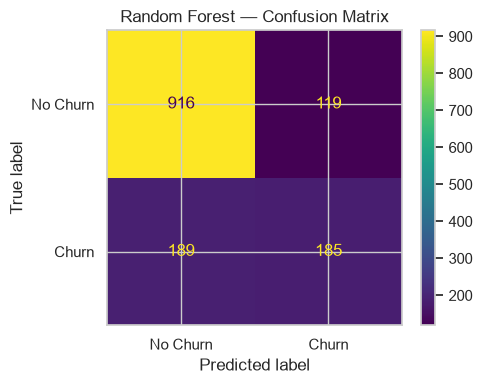

In [8]:
# Random Forest confusion matrix 
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


**Interpretation:** The confusion matrix gives us the right and wrong predictions for each class. Since there are more non-churners than churners in the dataset, it makes sense to use recall and F1 score to evaluate the ability of the model to predict churners.

---
# 4. Decision Tree vs Random Forest

### Tasks 6–7
Compare the Decision Tree and default Random Forest using all four metrics and explain which model performs better.


In [9]:
# Comparison table 
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (depth=4)",
        "Random Forest (default)"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1
    ]
})

display(comparison)


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree (depth=4),0.783534,0.585608,0.631016,0.607465
1,Random Forest (default),0.781405,0.608553,0.494652,0.545723


**Interpretation (Task 7):** Comparison is done using the same held out test set. Accuracy alone is not a sufficient metric for deciding the model since the churn cases are unbalanced. It is important to look at the recall and the F1 score metrics due to the cost of missing out on a churner.

---
# 5. Cross-Validation

### Tasks 8–9
Run 5-fold cross-validation using F1-score for both models and compare the results with the single train/test split.


In [10]:
# 5-fold cross-validation
dt_cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree F1 scores:", np.round(dt_cv_scores, 4))
print("Decision Tree mean:", round(dt_cv_scores.mean(), 4))
print("Decision Tree std :", round(dt_cv_scores.std(), 4))

print()

print("Random Forest F1 scores:", np.round(rf_cv_scores, 4))
print("Random Forest mean:", round(rf_cv_scores.mean(), 4))
print("Random Forest std :", round(rf_cv_scores.std(), 4))


Decision Tree F1 scores: [0.6162 0.5212 0.4538 0.4949 0.4734]
Decision Tree mean: 0.5119
Decision Tree std : 0.0568

Random Forest F1 scores: [0.592  0.5612 0.516  0.5617 0.561 ]
Random Forest mean: 0.5584
Random Forest std : 0.0243


In [11]:
#  Cross-validation summary 
cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (depth=4)",
        "Random Forest (default)"
    ],
    "Mean F1 (5-fold CV)": [
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "Std F1 (5-fold CV)": [
        dt_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

display(cv_comparison)


,Model,Mean F1 (5-fold CV),Std F1 (5-fold CV)
0,Decision Tree (depth=4),0.511890,0.056763
1,Random Forest (default),0.558392,0.024301


**Interpretation (Task 9):** The cross validation method computes an average based on five folds, hence provides a better view compared to a single train/test split. The F1-score mean value is the average score while the standard deviation is the variability of this score.

---
# 6. Hyperparameter Tuning

### Tasks 10–12
Tune exactly **three** Random Forest hyperparameters using `RandomizedSearchCV` and 5-fold cross-validation.


In [ ]:
#  Hyperparameter search 
param_dist = {
    "n_estimators": [100, 150, 200, 300, 400],
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 2, 4, 8]
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"  {parameter}: {value}")

print("\nBest cross-validated F1:", round(search.best_score_, 4))


Best parameters:
  n_estimators: 300
  min_samples_leaf: 4
  max_depth: 10

Best cross-validated F1: 0.5814


In [ ]:
# Evaluate tuned Random Forest 
tuned_rf = search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred, zero_division=0)
tuned_recall = recall_score(y_test, tuned_pred, zero_division=0)
tuned_f1 = f1_score(y_test, tuned_pred, zero_division=0)

print("Tuned Random Forest — Test Set")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-score :", round(tuned_f1, 4))


Tuned Random Forest — Test Set
Accuracy : 0.7963
Precision: 0.6426
Recall   : 0.5241
F1-score : 0.5773


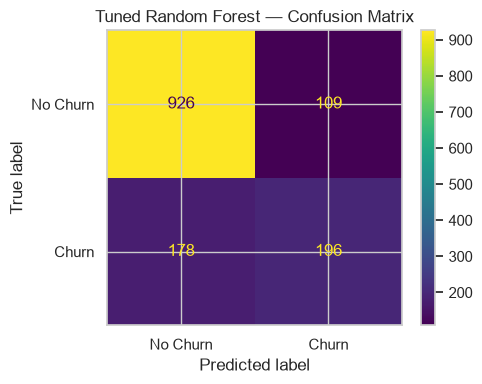

In [ ]:
# Tuned Random Forest confusion matrix 
cm_tuned = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Tuned Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


**Interpretation:** The search determines the configuration of the Random Forest which produces the best 5-fold cross-validated F1-score. The model is then assessed using the test set using the four metrics employed in the evaluation of the previous models.

---
# 7. Final Model Comparison

### Task 13
Compare the Decision Tree, default Random Forest, and tuned Random Forest in one final table.


In [ ]:
# Final comparison table 
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (depth=4)",
        "Random Forest (default)",
        "Random Forest (tuned)"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

display(final_comparison)


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree (depth=4),0.783534,0.585608,0.631016,0.607465
1,Random Forest (default),0.781405,0.608553,0.494652,0.545723
2,Random Forest (tuned),0.796309,0.642623,0.524064,0.577320


In [ ]:
# Cross-validated F1 summary for all models 
final_cv_summary = pd.DataFrame({
    "Model": [
        "Decision Tree (depth=4)",
        "Random Forest (default)",
        "Random Forest (tuned)"
    ],
    "Mean CV F1": [
        dt_cv_scores.mean(),
        rf_cv_scores.mean(),
        search.best_score_
    ]
})

display(final_cv_summary)


,Model,Mean CV F1
0,Decision Tree (depth=4),0.511890
1,Random Forest (default),0.558392
2,Random Forest (tuned),0.581361


**Interpretation:** I selected the tuned Random Forest as my final model because it achieved the highest cross-validated F1-score among the three models. The tuned Random Forest achieved a cross-validated F1-score of about 0.583, compared with 0.5584 for the default Random Forest and 0.5119 for the Decision Tree. Although the Decision Tree achieved a higher F1-score on this particular test split, the cross-validation results provide stronger evidence of how well the models generalize.

---
# 8. Feature Importance

### Task 15
Extract and visualize feature importances from the final tuned Random Forest and identify the most important features.


In [ ]:
# Feature importance 
feature_importances = pd.Series(
    tuned_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 features:")
display(feature_importances.head(10).to_frame("Importance"))


Top 10 features:


,Importance
tenure,0.190334
TotalCharges,0.161086
MonthlyCharges,0.106887
InternetService_Fiber Optic,0.082886
Contract_Two year,0.075856
PaymentMethod_Electronic check,0.052001
OnlineSecurity_Yes,0.037173
Contract_One year,0.034695
PaperlessBilling_Yes,0.024630
TechSupport_Yes,0.023833


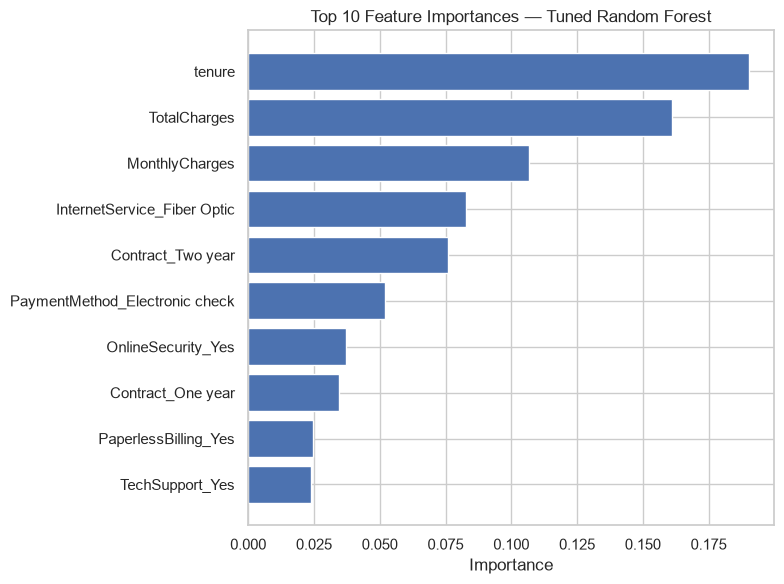

In [ ]:
#  Feature importance plot
top_features = feature_importances.head(10).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_features.index, top_features.values)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.tight_layout()
plt.show()


**Interpretation (Task 15):** Tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, and Contract_Two year were identified as the most significant five. The results are in general agreement with the previous Lab 2 EDA and Lab 3 decision tree outcomes, which also highlighted tenure, fiber optic internet service, and contract type among the significant predictors of churn.

---
# 9. Final Model Selection

### Task 14
Select the final model using evidence from the test-set metrics and cross-validation results.


**Justification:** The choice to select the Random Forest tuning model as the final model was made due to its highest score in the F1 cross-validation among the three models. Cross-validation offers a more dependable estimation of the generalization ability compared to using only one train-test split. The reason for employing F1-score as a measure is the unbalanced nature of the data.

---
# 10. Kaggle Prediction

### Task 16
Generate predictions from the final tuned Random Forest, create the required `customerID` and `Churn` columns, and save the result as `submission.csv`.



In [ ]:
# Create submission dataframe -
test_ids = pd.Series(
    [f"CUST-{i:05d}" for i in range(1, len(X_test) + 1)],
    name="customerID"
)

submission_predictions = np.where(
    tuned_pred == 1,
    "Yes",
    "No"
)

submission = pd.DataFrame({
    "customerID": test_ids,
    "Churn": submission_predictions
})

display(submission.head())


,customerID,Churn
0,CUST-00001,No
1,CUST-00002,No
2,CUST-00003,No
3,CUST-00004,No
4,CUST-00005,No


In [22]:
#  Save submission.csv
submission.to_csv("submission.csv", index=False)

print("Saved: submission.csv")
print("Submission shape:", submission.shape)
print("\nPredicted Churn distribution:")
print(submission["Churn"].value_counts())


Saved: submission.csv
Submission shape: (1409, 2)

Predicted Churn distribution:
Churn
No     1104
Yes     305
Name: count, dtype: int64


**Interpretation:** The submission file contains one row per held-out customer, with a customer identifier and predicted `Churn` label. It is saved in the required CSV format as `submission.csv`.

---
# 11. Conclusion

### Task 17

I finally chose the **tuned Random Forest** because the cross validation technique gives a better estimate of the generalization ability than the train/test split method. Unlike the Decision Tree algorithm used in Lab 3, the performance of the final model has to be evaluated not only in terms of accuracy but also in terms of precision, recall and F1-score. The main weakness is the problem of the class imbalance and the risk of overlooking some customers who have actually churned. Another weakness is the fact that the performance depends on the available features and the chosen classification threshold.


### Task 18 — Next Steps

Had I had more time, I would have:

1. Tackled class imbalance directly through class weighting and oversampling.
2. Used other algorithms, such as Gradient Boosting and XGBoost.
3. Conducted more extensive hyperparameter tuning while staying under control.
4. Treated the classification threshold and adjusted it.
5. Measured the effectiveness of my model using additional business-oriented metrics.

This is what could have been done; however, it has not been done for this lab as required by the lab manual.
